# Project 02 — Black-Scholes, Greeks & Derivatives Risk

## Notebook 01 — Options & Market Data

This notebook establishes the market-data and conceptual foundation for the
derivatives pricing and risk engine.

The notebook will:

- Introduce fundamental option concepts
- Explain calls, puts, moneyness, payoff, and profit
- Retrieve real option-chain data using `yfinance`
- Clean and validate option-market data
- Construct variables required for derivatives pricing
- Explore the relationship between strike, maturity, price, and implied volatility
- Prepare a clean dataset for the Black-Scholes pricing engine

## 1. Objective

The objective of this notebook is to establish a clean and reliable option market dataset that can be used throughout the derivatives risk engine.

Unlike a purely theoretical implementation, this project uses observed market data. This allows us to compare model-derived values with actual market prices and investigate where theoretical assumptions differ from market behavior.

### Workflow

$$\text{Market Data} \rightarrow \text{Data Cleaning} \rightarrow \text{Derived Variables} \rightarrow \text{Exploratory Analysis} \rightarrow \text{Pricing Model}$$

### Downstream Applications

The cleaned dataset produced here will be used by subsequent notebooks for:

* **Black-Scholes pricing**
* **Greeks calculation**
* **Implied volatility estimation**
* **Volatility-surface construction**
* **Monte Carlo pricing**
* **Hedging analysis**
* **Derivatives risk analysis**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

## 2. Market Data

### 2.1 Underlying Selection

For the initial analysis, we use the SPDR S&P 500 ETF Trust (`SPY`).

SPY is selected because:

- It has a highly liquid options market
- It has numerous strikes across multiple expirations
- It provides sufficient observations for volatility and risk analysis
- Its options are widely used for derivatives-market analysis

The underlying will be treated as the reference asset for the option chain
throughout this notebook.

In [3]:
ticker_symbol = "SPY"

ticker = yf.Ticker(ticker_symbol)
spot = ticker.history(interval='1d')['Close'].iloc[-1]
spot

np.float64(774.8862915039062)

### 2.2 Available Option Expirations

An option contract is defined not only by its strike and type, but also by its
expiration date.

We first retrieve the available expiration dates for the underlying.

In [4]:
expirations = ticker.options
len(expirations), expirations[:10]

(30,
 ('2026-10-07',
  '2026-10-08',
  '2026-10-09',
  '2026-10-12',
  '2026-10-13',
  '2026-10-14',
  '2026-10-15',
  '2026-10-16',
  '2026-10-23',
  '2026-10-30'))

### 2.3 Selecting an Expiration

For the initial analysis, we select an expiration approximately 30–45 days
from the valuation date.

This provides a reasonably liquid option chain while avoiding contracts that
are extremely close to expiration.

In [5]:
valuation_date = pd.Timestamp.today().normalize()
expiration_dates = pd.to_datetime(expirations)
days_to_expiry = (expiration_dates - valuation_date).days

target_days = 45

expiration_index = np.argmin(
    np.abs(days_to_expiry - target_days)
)

selected_expiration = expiration_dates[expiration_index]

selected_expiration

Timestamp('2026-11-20 00:00:00')

In [6]:
days_to_expiry = (
    selected_expiration - valuation_date
).days

days_to_expiry

44

### 2.4 Retrieve the Option Chain

The option chain contains separate datasets for calls and puts.

Each contract contains market information such as:

- Strike price
- Bid price
- Ask price
- Last traded price
- Volume
- Open interest
- Implied volatility
- Contract identifier

In [7]:
option_chain = ticker.option_chain(
    selected_expiration.strftime("%Y-%m-%d")
)

calls = option_chain.calls.copy()
puts = option_chain.puts.copy()

In [8]:
calls.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY261120C00300000,2026-09-17 20:10:34+00:00,300.0,463.12,474.04,478.23,0.0,0.0,5.0,89,1.267582,True,REGULAR,USD
1,SPY261120C00310000,2026-09-17 16:55:29+00:00,310.0,452.38,464.72,467.70,0.0,0.0,NaN,2,1.237309,True,REGULAR,USD
2,SPY261120C00320000,2026-09-25 17:05:17+00:00,320.0,453.18,454.20,458.02,0.0,0.0,10.0,10,1.184086,True,REGULAR,USD
3,SPY261120C00325000,2026-06-12 16:13:09+00:00,325.0,419.74,431.32,434.78,0.0,0.0,NaN,1,0.000010,True,REGULAR,USD
4,SPY261120C00340000,2026-06-12 13:40:45+00:00,340.0,400.80,416.60,420.11,0.0,0.0,NaN,1,0.000010,True,REGULAR,USD


In [9]:
puts.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY261120P00300000,2026-10-06 18:36:35+00:00,300.0,0.01,0.01,0.02,0.0,0.0,11.0,5266,0.812502,False,REGULAR,USD
1,SPY261120P00305000,2026-10-06 18:39:36+00:00,305.0,0.01,0.01,0.02,0.0,0.0,20.0,1899,0.796877,False,REGULAR,USD
2,SPY261120P00310000,2026-09-30 13:43:53+00:00,310.0,0.02,0.01,0.02,0.0,0.0,22.0,278,0.781252,False,REGULAR,USD
3,SPY261120P00315000,2026-10-05 13:35:47+00:00,315.0,0.02,0.01,0.02,0.0,0.0,2.0,646,0.769534,False,REGULAR,USD
4,SPY261120P00320000,2026-10-06 18:40:44+00:00,320.0,0.02,0.01,0.02,0.0,0.0,30.0,481,0.757815,False,REGULAR,USD


## 3. Standardizing the Option Chain

The raw option chain contains contracts across a wide range of strikes and
liquidity levels.

For the analysis that follows, calls and puts are combined into a common
structure and a small number of useful variables are derived.

The objective is not to build a production-grade data pipeline, but to create
a clean market dataset suitable for option pricing and risk analysis.

In [14]:
calls_clean = calls.copy()
puts_clean = puts.copy()

calls_clean["option_type"] = "call"
puts_clean["option_type"] = "put"

calls_clean["expiration"] = selected_expiration
puts_clean["expiration"] = selected_expiration

options = pd.concat(
    [calls_clean, puts_clean],
    ignore_index=True
)
options

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,option_type,expiration
0,SPY261120C00300000,2026-09-17 20:10:34+00:00,300.0,463.12,474.04,478.23,0.0,0.0,5.0,89,1.267582,True,REGULAR,USD,call,2026-11-20
1,SPY261120C00310000,2026-09-17 16:55:29+00:00,310.0,452.38,464.72,467.70,0.0,0.0,NaN,2,1.237309,True,REGULAR,USD,call,2026-11-20
2,SPY261120C00320000,2026-09-25 17:05:17+00:00,320.0,453.18,454.20,458.02,0.0,0.0,10.0,10,1.184086,True,REGULAR,USD,call,2026-11-20
3,SPY261120C00325000,2026-06-12 16:13:09+00:00,325.0,419.74,431.32,434.78,0.0,0.0,NaN,1,0.000010,True,REGULAR,USD,call,2026-11-20
4,SPY261120C00340000,2026-06-12 13:40:45+00:00,340.0,400.80,416.60,420.11,0.0,0.0,NaN,1,0.000010,True,REGULAR,USD,call,2026-11-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,SPY261120P00920000,2026-09-14 16:45:06+00:00,920.0,159.07,142.99,146.87,0.0,0.0,NaN,0,0.294807,True,REGULAR,USD,put,2026-11-20
386,SPY261120P00950000,2026-09-18 19:49:11+00:00,950.0,188.38,172.98,176.79,0.0,0.0,1.0,0,0.334418,True,REGULAR,USD,put,2026-11-20
387,SPY261120P00960000,2026-08-04 14:08:57+00:00,960.0,195.82,189.24,192.76,0.0,0.0,NaN,0,0.491643,True,REGULAR,USD,put,2026-11-20
388,SPY261120P00995000,2026-09-18 20:04:57+00:00,995.0,232.85,218.13,221.87,0.0,0.0,20.0,0,0.396857,True,REGULAR,USD,put,2026-11-20


In [15]:
options = options[
    [
        "contractSymbol",
        "option_type",
        "expiration",
        "strike",
        "lastPrice",
        "bid",
        "ask",
        "volume",
        "openInterest",
        "impliedVolatility",
        "inTheMoney"
    ]
].copy()

options = options.rename(
    columns={
        "contractSymbol": "contract_symbol",
        "lastPrice": "last_price",
        "openInterest": "open_interest",
        "impliedVolatility": "implied_volatility",
        "inTheMoney": "in_the_money"
    }
)

In [17]:
options["spot"] = spot

options["days_to_expiry"] = days_to_expiry

options["T"] = (
    options["days_to_expiry"] / 365
)

options

,contract_symbol,option_type,expiration,strike,last_price,bid,ask,volume,open_interest,implied_volatility,in_the_money,spot,days_to_expiry,T
0,SPY261120C00300000,call,2026-11-20,300.0,463.12,474.04,478.23,5.0,89,1.267582,True,774.886292,44,0.120548
1,SPY261120C00310000,call,2026-11-20,310.0,452.38,464.72,467.70,NaN,2,1.237309,True,774.886292,44,0.120548
2,SPY261120C00320000,call,2026-11-20,320.0,453.18,454.20,458.02,10.0,10,1.184086,True,774.886292,44,0.120548
3,SPY261120C00325000,call,2026-11-20,325.0,419.74,431.32,434.78,NaN,1,0.000010,True,774.886292,44,0.120548
4,SPY261120C00340000,call,2026-11-20,340.0,400.80,416.60,420.11,NaN,1,0.000010,True,774.886292,44,0.120548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,SPY261120P00920000,put,2026-11-20,920.0,159.07,142.99,146.87,NaN,0,0.294807,True,774.886292,44,0.120548
386,SPY261120P00950000,put,2026-11-20,950.0,188.38,172.98,176.79,1.0,0,0.334418,True,774.886292,44,0.120548
387,SPY261120P00960000,put,2026-11-20,960.0,195.82,189.24,192.76,NaN,0,0.491643,True,774.886292,44,0.120548
388,SPY261120P00995000,put,2026-11-20,995.0,232.85,218.13,221.87,20.0,0,0.396857,True,774.886292,44,0.120548


## 4. Derived Market Variables

### 4.1 Mid-Price

The bid-ask midpoint is used as the primary estimate of the current market
price:

$$
P_{\text{mid}} = \frac{\text{Bid} + \text{Ask}}{2}
$$

The last traded price is retained for reference but is not treated as the
current market price because it may reflect an earlier transaction.

### 4.2 Moneyness

Moneyness describes the relationship between the underlying price and strike.

We use:

$$
\text{Moneyness} = \frac{K}{S}
$$

where values below 1 indicate strikes below spot and values above 1 indicate
strikes above spot.

For the pricing analysis, let's remove contracts where we don't have a meaningful quote:

In [18]:
options['mid_price'] = (options['bid'] + options['ask']) / 2
options['moneyness'] = options['strike'] / options['spot']

Then restrict the analysis to a reasonable range around spot:

In [19]:
options = options[
    (options["bid"] > 0) &
    (options["ask"] > 0) &
    (options["ask"] >= options["bid"]) &
    (options["mid_price"] > 0)
].copy()

options = options[
    options["moneyness"].between(0.80, 1.20)
].copy()

This is not saying that options outside this range are "bad." We're simply creating a usable analytical subset and avoiding extremely deep ITM/OTM contracts where quotes and IV can become less informative.

### 4.1 Intrinsic Value

For a call:

$$
\text{IV} = \max(S - K, 0)
$$

For a put:

$$
\text{IV} = \max(K - S, 0)
$$

The difference between the option's market price and intrinsic value represents
its time value.

In [20]:
options["intrinsic_value"] = np.where(
    options["option_type"].eq("call"),
    np.maximum(options["spot"] - options["strike"], 0),
    np.maximum(options["strike"] - options["spot"], 0)
)

options["time_value"] = (
    options["mid_price"] - options["intrinsic_value"]
)

In [21]:
options = options[
    [
        "contract_symbol",
        "option_type",
        "expiration",
        "spot",
        "strike",
        "days_to_expiry",
        "T",
        "moneyness",
        "bid",
        "ask",
        "mid_price",
        "last_price",
        "volume",
        "open_interest",
        "implied_volatility",
        "intrinsic_value",
        "time_value",
        "in_the_money"
    ]
].sort_values(
    ["option_type", "strike"]
).reset_index(drop=True)

In [22]:
options.head(10)

,contract_symbol,option_type,expiration,spot,strike,days_to_expiry,T,moneyness,bid,ask,mid_price,last_price,volume,open_interest,implied_volatility,intrinsic_value,time_value,in_the_money
0,SPY261120C00620000,call,2026-11-20,774.886292,620.0,44,0.120548,0.800117,156.37,160.18,158.275,158.81,6.0,45,0.485814,154.886292,3.388708,True
1,SPY261120C00625000,call,2026-11-20,774.886292,625.0,44,0.120548,0.806570,151.51,155.25,153.380,154.00,2.0,7,0.474035,149.886292,3.493708,True
2,SPY261120C00630000,call,2026-11-20,774.886292,630.0,44,0.120548,0.813023,147.20,150.37,148.785,145.85,2.0,785,0.463384,144.886292,3.898708,True
3,SPY261120C00635000,call,2026-11-20,774.886292,635.0,44,0.120548,0.819475,142.34,144.60,143.470,134.00,2.0,141,0.431982,139.886292,3.583708,True
4,SPY261120C00640000,call,2026-11-20,774.886292,640.0,44,0.120548,0.825928,137.35,139.56,138.455,138.85,1.0,414,0.418005,134.886292,3.568708,True
5,SPY261120C00645000,call,2026-11-20,774.886292,645.0,44,0.120548,0.832380,131.80,135.54,133.670,124.21,8.0,69,0.426886,129.886292,3.783708,True
6,SPY261120C00650000,call,2026-11-20,774.886292,650.0,44,0.120548,0.838833,127.50,129.68,128.590,124.27,1.0,2077,0.394781,124.886292,3.703708,True
7,SPY261120C00655000,call,2026-11-20,774.886292,655.0,44,0.120548,0.845285,122.59,124.84,123.715,130.75,5.0,180,0.385321,119.886292,3.828708,True
8,SPY261120C00660000,call,2026-11-20,774.886292,660.0,44,0.120548,0.851738,117.68,121.25,119.465,125.55,3.0,338,0.400702,114.886292,4.578708,True
9,SPY261120C00665000,call,2026-11-20,774.886292,665.0,44,0.120548,0.858190,112.79,115.00,113.895,119.35,30.0,154,0.362555,109.886292,4.008708,True


In [23]:
options.shape

(256, 18)

In [24]:
assert (options["bid"] > 0).all()
assert (options["ask"] >= options["bid"]).all()
assert (options["mid_price"] > 0).all()
assert (options["T"] > 0).all()
assert options["option_type"].isin(["call", "put"]).all()

In [25]:
options.groupby("option_type").size()

option_type
call    129
put     127
dtype: int64

In [26]:
options.groupby("option_type")[
    ["strike", "mid_price", "implied_volatility", "volume", "open_interest"]
].agg(["min", "max", "mean"])

strike                    mid_price                      \
               min    max        mean       min      max       mean   
option_type                                                           
call         620.0  925.0  764.201550     0.015  158.275  38.076318   
put          620.0  920.0  746.740157     0.625  144.930  13.617638   

            implied_volatility                     volume           \
                           min       max      mean    min      max   
option_type                                                          
call                  0.118966  0.485814  0.204705    1.0   2024.0   
put                   0.084787  0.315681  0.165513    1.0  19523.0   

                        open_interest                       
                   mean           min     max         mean  
option_type                                                 
call         101.152542             1   46221  2553.720930  
put          516.161290             0  163785  8533.251969

In [27]:
options.isna().sum()

contract_symbol        0
option_type            0
expiration             0
spot                   0
strike                 0
days_to_expiry         0
T                      0
moneyness              0
bid                    0
ask                    0
mid_price              0
last_price             0
volume                14
open_interest          0
implied_volatility     0
intrinsic_value        0
time_value             0
in_the_money           0
dtype: int64

## 5. Market Analysis

### 5.1 Option Price Across Strike Prices

Option prices vary systematically with the strike price.

For a fixed expiration:

- Call prices generally decrease as strike increases.
- Put prices generally increase as strike increases.
- The relationship is nonlinear because option value depends on both
  intrinsic value and time value.

The observed market prices provide the benchmark against which theoretical
pricing models will later be evaluated.

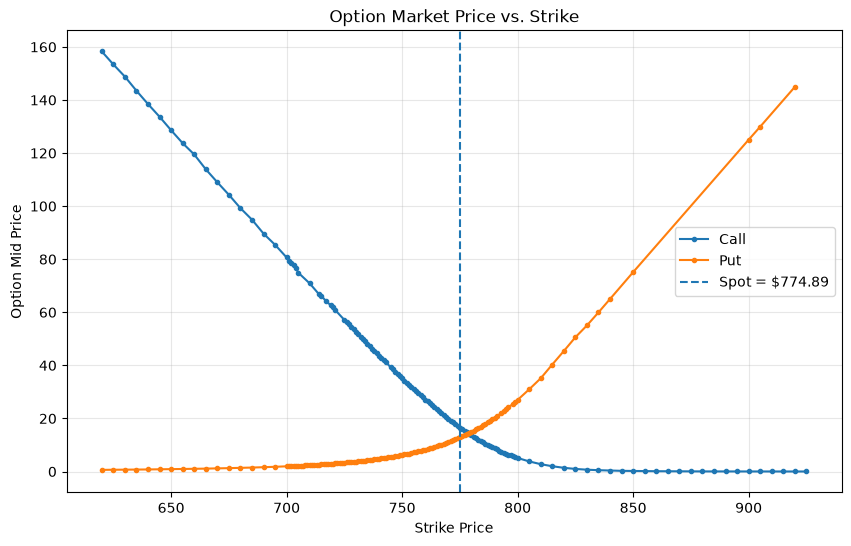

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

for option_type, group in options.groupby("option_type"):
    ax.plot(
        group["strike"],
        group["mid_price"],
        marker="o",
        markersize=3,
        label=option_type.capitalize()
    )

ax.axvline(
    spot,
    linestyle="--",
    label=f"Spot = ${spot:.2f}"
)

ax.set_title("Option Market Price vs. Strike")
ax.set_xlabel("Strike Price")
ax.set_ylabel("Option Mid Price")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

### 5.2 Implied Volatility and Moneyness

Implied volatility is not necessarily constant across option strikes.

If implied volatility varies systematically with strike, the resulting pattern
is commonly referred to as the volatility smile or volatility skew.

We examine the observed implied volatility across moneyness to identify this
relationship in the market data.

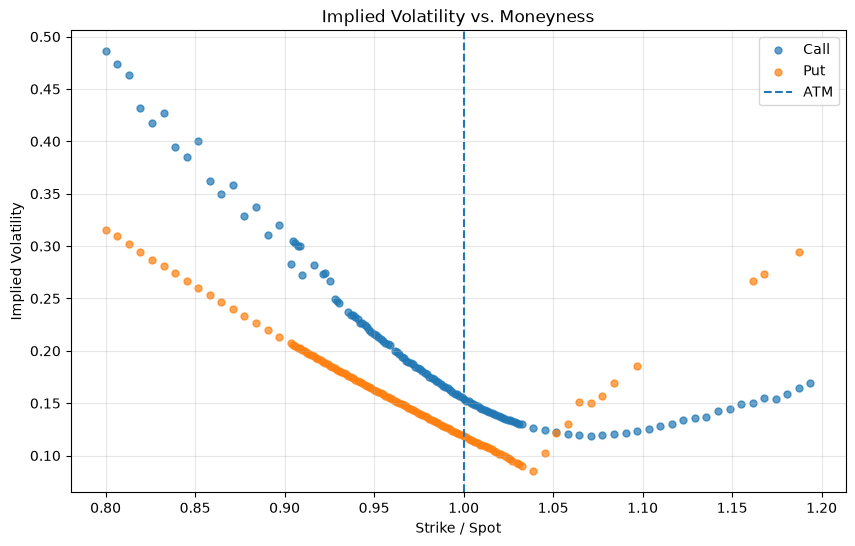

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

for option_type, group in options.groupby("option_type"):
    ax.scatter(
        group["moneyness"],
        group["implied_volatility"],
        s=25,
        alpha=0.7,
        label=option_type.capitalize()
    )

ax.axvline(
    1.0,
    linestyle="--",
    label="ATM"
)

ax.set_title("Implied Volatility vs. Moneyness")
ax.set_xlabel("Strike / Spot")
ax.set_ylabel("Implied Volatility")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

### 5.3 Option Payoffs

At expiration, the payoff of a European call is:

$$
\max(S_T - K, 0)
$$

and the payoff of a European put is:

$$
\max(K - S_T, 0)
$$

These payoff functions describe the contractual value at expiration and do
not include the premium paid to purchase the option.

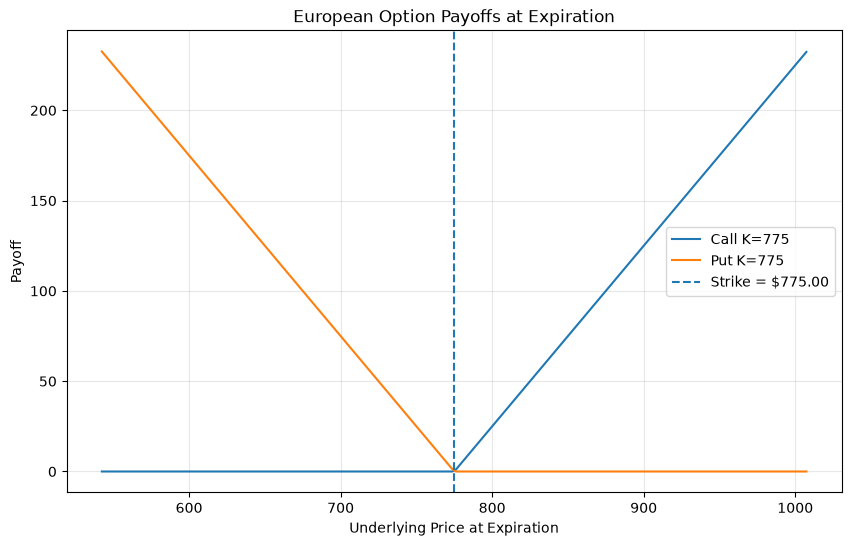

In [30]:
atm_strike = options.loc[
    (options["strike"] - spot).abs().idxmin(),
    "strike"
]

terminal_prices = np.linspace(
    spot * 0.7,
    spot * 1.3,
    200
)

call_payoff = np.maximum(
    terminal_prices - atm_strike,
    0
)

put_payoff = np.maximum(
    atm_strike - terminal_prices,
    0
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    terminal_prices,
    call_payoff,
    label=f"Call K={atm_strike:.0f}"
)

ax.plot(
    terminal_prices,
    put_payoff,
    label=f"Put K={atm_strike:.0f}"
)

ax.axvline(
    atm_strike,
    linestyle="--",
    label=f"Strike = ${atm_strike:.2f}"
)

ax.set_title("European Option Payoffs at Expiration")
ax.set_xlabel("Underlying Price at Expiration")
ax.set_ylabel("Payoff")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

## 6. Key Takeaways

This notebook established the market-data foundation for the derivatives risk
engine using real SPY option-chain data.

### Key observations

- An option's value depends on the underlying price, strike price, time to
  expiration, volatility, interest rates, and dividends.
- Calls and puts have fundamentally different payoff profiles, while their
  prices are linked through put-call parity.
- Moneyness provides a useful framework for comparing options across different
  strike prices.
- The raw option chain contains contracts with very different levels of
  liquidity and informational quality. Bid-ask spreads, open interest, and
  trading volume therefore need to be considered when analyzing market prices.
- The bid-ask midpoint provides a more appropriate estimate of the current
  market price than the last traded price when evaluating the option chain.
- Implied volatility varies across strikes rather than remaining constant.
  This provides an initial indication of the volatility smile/skew observed in
  real option markets.
- The cleaned dataset contains both call and put contracts across a range of
  strikes surrounding the current SPY spot price.

### Limitations

The option chain represents a market snapshot at a particular point in time.
Market prices, implied volatilities, liquidity, and available contracts change
continuously.

The implied volatility reported by the market data provider is treated as an
observed market input at this stage. Subsequent notebooks will independently
calculate implied volatility from observed option prices.

### Transition to Black-Scholes Pricing

The next notebook uses the cleaned market observations to implement the
Black-Scholes model.

The central question becomes:

> How well does the Black-Scholes model explain the prices observed in the
> market?

The model-derived option values will be compared with observed market prices,
providing the foundation for subsequent analysis of Greeks, implied
volatility, volatility surfaces, Monte Carlo pricing, hedging, and derivatives
risk.